In [4]:
import numpy as np
from pathlib import Path

# Load results for an environment
results_dir = Path("../results/evaluation")
data = np.load(results_dir / "hopper_results.npz", allow_pickle=True)

# See what's inside
#print("Keys:", sorted(data.keys()))
#print("Environment:", data["env"])
#print("Methods:", data["methods"])
#print("Stride:", data["stride"])

# Extract metadata
methods = list(data["methods"])
fail_steps = data["fail_steps"]
timesteps = data["timesteps"]

# Print summary metrics per method
for m in methods:
  print(f"\n--- {m} ---")
  print(f"  pAUROC@10%:  {data[f'pauroc_{m}']:.4f}")
  print(f"  FPR:         {data[f'fpr_{m}']:.1f}%")
  print(f"  Det Rate:    {data[f'det_rate_{m}']:.1f}%")
  print(f"  Med TTD:     {data[f'med_ttd_{m}']}")
  print(f"  Threshold:   {data[f'threshold_{m}']:.4f}")


--- rec ---
  pAUROC@10%:  0.9745
  FPR:         26.5%
  Det Rate:    100.0%
  Med TTD:     357.0
  Threshold:   3.4477

--- knn ---
  pAUROC@10%:  0.8196
  FPR:         20.3%
  Det Rate:    100.0%
  Med TTD:     299.0
  Threshold:   3.4951

--- iforest ---
  pAUROC@10%:  0.6796
  FPR:         63.0%
  Det Rate:    100.0%
  Med TTD:     433.0
  Threshold:   2.3156

--- fft ---
  pAUROC@10%:  0.5583
  FPR:         33.7%
  Det Rate:    100.0%
  Med TTD:     313.0
  Threshold:   4.1917

--- sig ---
  pAUROC@10%:  0.9294
  FPR:         58.7%
  Det Rate:    98.4%
  Med TTD:     501.5
  Threshold:   1.9659

--- basis ---
  pAUROC@10%:  0.9129
  FPR:         32.1%
  Det Rate:    100.0%
  Med TTD:     377.0
  Threshold:   4.3126

--- dist ---
  pAUROC@10%:  0.4737
  FPR:         37.2%
  Det Rate:    100.0%
  Med TTD:     309.0
  Threshold:   2.6191


In [58]:
def lead_and_fpr(env: str):
    data = np.load(results_dir / f"{env}_results.npz", allow_pickle=True)
    lead = [data[f'det_rate_{m}'] * data[f'med_ttd_{m}'] / 100 for m in methods]
    fpr = [data[f'fpr_{m}'] for m in methods]
    return lead, fpr


def lead_fpr_plot(env: str, ax=None):
    data = np.load(results_dir / f"{env}_results.npz", allow_pickle=True)
    methods = data['methods']
    lead, fpr = lead_and_fpr(env)
    for m, l, f in zip(methods, lead, fpr):
        ax.scatter(l, f, label=m)
    ax.legend()

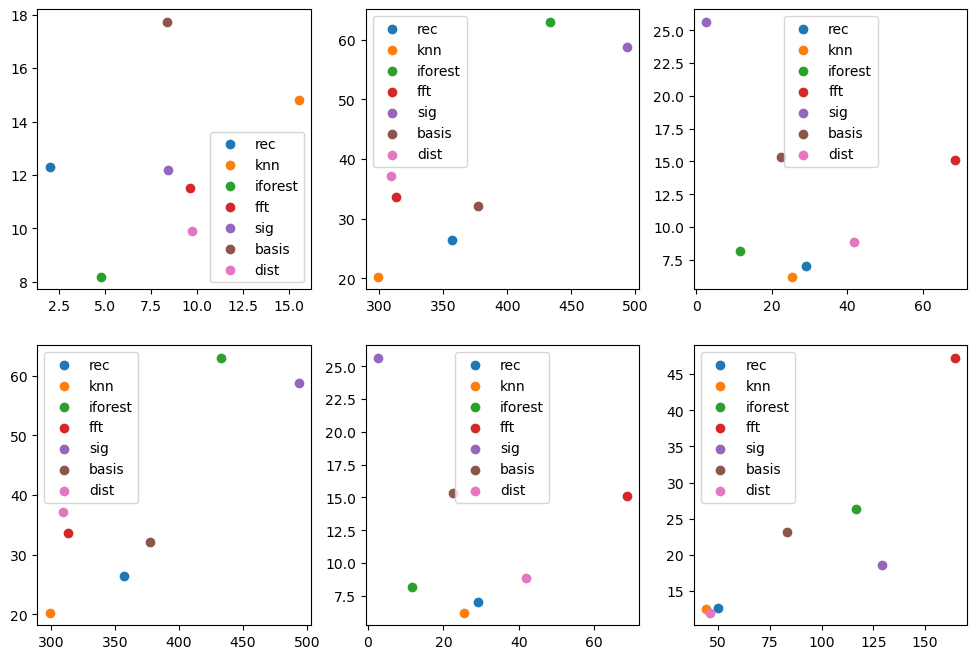

In [66]:
envs = ['inv_pend', 'hopper', 'half_cheetah', 'ant', 'humanoid', 'upkie']
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for i in range(2):
    for j in range(3):
        lead_fpr_plot(envs[i+j], ax[i,j])

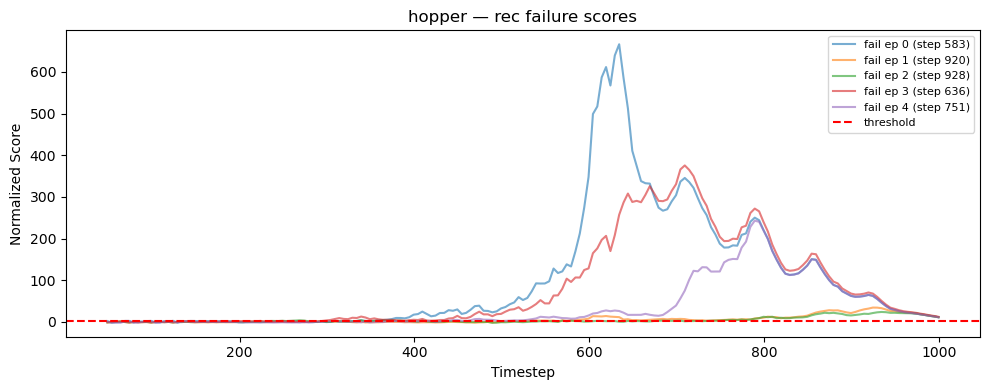

In [61]:
# Load score curves for one method
method = methods[0]
n_success = int(data["n_test_success"])
n_failure = int(data["n_test_failure"])

success_scores = [data[f"scores_success_{method}_{i}"] for i in range(n_success)]
failure_scores = [data[f"scores_failure_{method}_{i}"] for i in range(n_failure)]

# Quick plot: a few failure episodes with threshold
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
threshold = float(data[f"threshold_{method}"])

for i in range(min(5, n_failure)):
  t = timesteps[:len(failure_scores[i])]
  ax.plot(t, failure_scores[i], alpha=0.6, label=f"fail ep {i} (step {fail_steps[i]})")

ax.axhline(threshold, color="red", ls="--", label="threshold")
ax.set_xlabel("Timestep")
ax.set_ylabel("Normalized Score")
ax.set_title(f"{data['env']} — {method} failure scores")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()